<a href="https://colab.research.google.com/github/Akira006/orion-fl-dr-research/blob/main/notebooks/EyePACS/exp2_fl_loss_asc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Thu Apr 30 12:28:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   30C    P0             51W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# =========================
# CELL 1A — MOUNT GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =========================
# CELL 1B — IMPORTS + CONFIG
# =========================
import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tqdm.notebook import tqdm   # <-- tambahan untuk progress bar

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# PATH CONFIG
# =========================
DATASET_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training"
PROJECT_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research"

DATASET_NAME    = "EyePACS"
EXPERIMENT_NAME = "exp2_fl_loss_asc"
MODEL_NAME      = "mobilenet"

BASE_RESULT_DIR = os.path.join(PROJECT_DIR, "results", DATASET_NAME, EXPERIMENT_NAME, MODEL_NAME)
MODELS_DIR  = os.path.join(BASE_RESULT_DIR, "models")
LOGS_DIR    = os.path.join(BASE_RESULT_DIR, "logs")
FIGURES_DIR = os.path.join(BASE_RESULT_DIR, "figures")

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(LOGS_DIR,    exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

NPZ_PATH   = os.path.join(DATASET_DIR, "EyePACS_dataset_224.npz")
LABEL_PATH = os.path.join(DATASET_DIR, "trainLabels.csv")

# =========================
# FL CONFIG
# =========================
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
NUM_CLASSES   = 5
NUM_CLIENTS   = 3

EPOCHS_LOCAL_STAGE1 = 3
EPOCHS_LOCAL_STAGE2 = 3
FL_ROUNDS           = 10

LEARNING_RATE_STAGE1 = 1e-3
LEARNING_RATE_STAGE2 = 1e-6

UNFREEZE_LAST_N_LAYERS = 10

SORT_STRATEGY = "loss_ascending"

# =========================
# DEBUG INFO
# =========================
print("TensorFlow version:", tf.__version__)
print("DATASET_DIR exists:", os.path.exists(DATASET_DIR))
print("PROJECT_DIR exists:", os.path.exists(PROJECT_DIR))
print("NPZ_PATH   :", NPZ_PATH)
print("NPZ exists :", os.path.exists(NPZ_PATH))
print("LABEL_PATH :", LABEL_PATH)
print("LABEL exists:", os.path.exists(LABEL_PATH))
print("\nnumpy  :", np.__version__)
print("pandas :", pd.__version__)
print("tf     :", tf.__version__)
print("\nAll imports OK.")

TensorFlow version: 2.20.0
DATASET_DIR exists: True
PROJECT_DIR exists: True
NPZ_PATH   : /content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/EyePACS_dataset_224.npz
NPZ exists : True
LABEL_PATH : /content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/trainLabels.csv
LABEL exists: True

numpy  : 2.0.2
pandas : 2.2.2
tf     : 2.20.0

All imports OK.


In [4]:
# =========================
# CELL 2 — CHECK DIRECTORY CONTENT
# =========================
if os.path.exists(DATASET_DIR):
    print("Files inside DATASET_DIR:")
    for f in os.listdir(DATASET_DIR):
        print("-", f)
else:
    print("DATASET_DIR not found.")

Files inside DATASET_DIR:
- trainLabels.csv
- train
- EyePACS_dataset_224.npz


In [5]:
# =========================
# CELL 3 — SANITY CHECK NPZ
# =========================
assert os.path.exists(NPZ_PATH), f"NPZ file tidak ditemukan: {NPZ_PATH}"

data = np.load(NPZ_PATH, allow_pickle=True)
print("Keys in NPZ:", data.files)

for k in data.files:
    arr = data[k]
    try:
        print(k, arr.shape, arr.dtype)
    except:
        print(k, type(arr))

Keys in NPZ: ['images', 'labels', 'filenames']
images (35126, 224, 224, 3) uint8
labels (35126,) int64
filenames (35126,) <U11


In [6]:
# =========================
# CELL 4 — LOAD NPZ + MERGE LABEL CSV
# =========================
assert os.path.exists(LABEL_PATH), f"Label CSV tidak ditemukan: {LABEL_PATH}"

data  = np.load(NPZ_PATH, allow_pickle=True)
X_raw = data["images"]
print("X_raw shape:", X_raw.shape)

label_df = pd.read_csv(LABEL_PATH)
print("\nLabel CSV head:")
print(label_df.head())
print("\nLabel CSV columns:", label_df.columns.tolist())
print("Label CSV shape:", label_df.shape)

# EyePACS kolom label biasanya 'level'
LABEL_COL = "level"
y_raw = label_df[LABEL_COL].values.astype(np.int64)

print("\ny_raw shape:", y_raw.shape)
print("Unique labels:", np.unique(y_raw))
print("\nOverall label distribution:")
print(pd.Series(y_raw).value_counts().sort_index())

assert len(X_raw) == len(y_raw), (
    f"Jumlah images ({len(X_raw)}) != jumlah label ({len(y_raw)}). "
    "Cek ulang urutan CSV vs NPZ."
)
print("\nImages dan label aligned — OK")

X_raw shape: (35126, 224, 224, 3)

Label CSV head:
      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1

Label CSV columns: ['image', 'level']
Label CSV shape: (35126, 2)

y_raw shape: (35126,)
Unique labels: [0 1 2 3 4]

Overall label distribution:
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64

Images dan label aligned — OK


In [7]:
# =========================
# CELL 5 — GLOBAL TRAIN/VAL/TEST SPLIT (70:15:15)
# =========================

# Step 1: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw,
    test_size=0.30,
    random_state=SEED,
    stratify=y_raw
)

# Step 2: temp 50/50 → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape  :", X_val.shape,   y_val.shape)
print("Test shape :", X_test.shape,  y_test.shape)

print("\nTrain label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nVal label distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest label distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train shape: (24588, 224, 224, 3) (24588,)
Val shape  : (5269, 224, 224, 3) (5269,)
Test shape : (5269, 224, 224, 3) (5269,)

Train label distribution:
0    18067
1     1710
2     3704
3      611
4      496
Name: count, dtype: int64

Val label distribution:
0    3871
1     367
2     794
3     131
4     106
Name: count, dtype: int64

Test label distribution:
0    3872
1     366
2     794
3     131
4     106
Name: count, dtype: int64


In [8]:
# =========================
# CELL 6 — PREPROCESS DATA
# =========================
X_train = X_train.astype("float32")
X_val   = X_val.astype("float32")
X_test  = X_test.astype("float32")

X_train = preprocess_input(X_train)
X_val   = preprocess_input(X_val)
X_test  = preprocess_input(X_test)

print("Preprocessing done.")
print("X_train dtype:", X_train.dtype)
print("X_val dtype  :", X_val.dtype)
print("X_test dtype :", X_test.dtype)

Preprocessing done.
X_train dtype: float32
X_val dtype  : float32
X_test dtype : float32


In [9]:
# =========================
# CELL 7 — PARTITION TRAIN DATA KE N CLIENTS (IID)
# =========================
def partition_iid(X, y, num_clients, seed=42):
    """
    Bagi data secara IID (stratified) ke num_clients client.
    Setiap client dapat porsi yang kira-kira sama dan distribusi kelas yang mirip.
    """
    np.random.seed(seed)
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    # Stratified split manual: kumpulkan index per kelas dulu
    class_indices = {}
    for cls in np.unique(y):
        class_indices[cls] = indices[y[indices] == cls]

    client_indices = [[] for _ in range(num_clients)]
    for cls, cidx in class_indices.items():
        splits = np.array_split(cidx, num_clients)
        for i, s in enumerate(splits):
            client_indices[i].extend(s.tolist())

    clients = []
    for i in range(num_clients):
        idx = np.array(client_indices[i])
        clients.append((X[idx], y[idx]))

    return clients

client_data = partition_iid(X_train, y_train, NUM_CLIENTS, seed=SEED)

print(f"Jumlah client: {NUM_CLIENTS}")
for i, (cx, cy) in enumerate(client_data):
    dist = pd.Series(cy).value_counts().sort_index().to_dict()
    print(f"  Client {i}: {len(cx)} samples | dist: {dist}")

Jumlah client: 3
  Client 0: 8198 samples | dist: {0: 6023, 1: 570, 2: 1235, 3: 204, 4: 166}
  Client 1: 8196 samples | dist: {0: 6022, 1: 570, 2: 1235, 3: 204, 4: 165}
  Client 2: 8194 samples | dist: {0: 6022, 1: 570, 2: 1234, 3: 203, 4: 165}


In [10]:
# =========================
# CELL 8 — BUILD TF DATASETS + LIGHT AUGMENTATION (PER CLIENT)
# =========================
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
], name="light_augmentation")

def augment_fn(x, y):
    x = data_augmentation(x, training=True)
    return x, y

def make_client_dataset(X, y, batch_size=BATCH_SIZE, augment=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    ds = ds.batch(batch_size)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# Val & Test DS (no augment)
val_ds  = tf.data.Dataset.from_tensor_slices((X_val,  y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("val_ds  ready")
print("test_ds ready")
print("Client datasets will be built per-round dynamically.")

val_ds  ready
test_ds ready
Client datasets will be built per-round dynamically.


In [11]:
# =========================
# CELL 9 — COMPUTE CLASS WEIGHTS PER CLIENT
# =========================
def compute_client_class_weights(y, num_classes=NUM_CLASSES):
    classes = np.unique(y)
    cw_array = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y
    )
    cw = {int(c): float(w) for c, w in zip(classes, cw_array)}
    # Pastikan semua kelas ada
    for c in range(num_classes):
        if c not in cw:
            cw[c] = 1.0
    return cw

client_class_weights = []
for i, (cx, cy) in enumerate(client_data):
    cw = compute_client_class_weights(cy)
    client_class_weights.append(cw)
    print(f"Client {i} class weights: {cw}")

Client 0 class weights: {0: 0.27222314461231945, 1: 2.8764912280701753, 2: 1.3276113360323887, 3: 8.037254901960784, 4: 9.87710843373494}
Client 1 class weights: {0: 0.27220192627034207, 1: 2.8757894736842107, 2: 1.3272874493927125, 3: 8.035294117647059, 4: 9.934545454545454}
Client 2 class weights: {0: 0.272135503155098, 1: 2.8750877192982456, 2: 1.3280388978930309, 3: 8.072906403940888, 4: 9.932121212121212}


In [12]:
# =========================
# CELL 10 — DEFINE MODEL BUILDER
# =========================
def build_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=5):
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs  = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

In [13]:
# =========================
# CELL 11 — FEDERATED AVERAGING (FedAvg) UTILITY
# =========================
def get_model_weights(model):
    return model.get_weights()

def set_model_weights(model, weights):
    model.set_weights(weights)

def fedavg(global_weights, client_weights_list, client_sizes):
    """
    FedAvg: weighted average berdasarkan ukuran dataset client.
    """
    total = sum(client_sizes)
    averaged = []
    for layer_idx in range(len(global_weights)):
        layer_avg = np.sum(
            [
                (client_weights_list[i][layer_idx] * client_sizes[i] / total)
                for i in range(len(client_weights_list))
            ],
            axis=0
        )
        averaged.append(layer_avg)
    return averaged

print("FedAvg utility ready.")

FedAvg utility ready.


In [14]:
# =========================
# CELL 12 — LOSS-BASED CLIENT SORTING UTILITY
# =========================
def evaluate_client_loss(model, X, y, batch_size=BATCH_SIZE):
    """
    Hitung val loss client menggunakan data train mereka sendiri
    (sebagai proxy loss untuk sorting).
    """
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    loss, _ = model.evaluate(ds, verbose=0)
    return loss

def sort_clients_by_loss(model, client_data, strategy="loss_ascending"):
    """
    Urutkan client berdasarkan loss.
    strategy: 'loss_ascending' atau 'loss_descending'
    """
    losses = []
    for i, (cx, cy) in enumerate(client_data):
        loss = evaluate_client_loss(model, cx, cy)
        losses.append((i, loss))
        print(f"  Client {i} loss: {loss:.4f}")

    ascending = (strategy == "loss_ascending")
    sorted_clients = sorted(losses, key=lambda x: x[1], reverse=not ascending)
    order = [c[0] for c in sorted_clients]
    loss_values = {c[0]: c[1] for c in sorted_clients}

    print(f"\nSorted order ({strategy}): {order}")
    return order, loss_values

print("Loss-based sorting utility ready.")

Loss-based sorting utility ready.


In [15]:
# =========================
# CELL 13 — LOCAL TRAINING UTILITY
# =========================
def local_train(
    global_weights,
    client_X, client_y,
    client_cw,
    base_model_ref,
    stage,
    epochs,
    lr
):
    """
    Bangun model lokal, load global weights, train lokal, return updated weights.
    stage: 1 (frozen base) atau 2 (partial unfreeze)
    """
    local_model, local_base = build_mobilenetv2_model(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        num_classes=NUM_CLASSES
    )
    local_model.set_weights(global_weights)

    if stage == 2:
        local_base.trainable = True
        for layer in local_base.layers[:-UNFREEZE_LAST_N_LAYERS]:
            layer.trainable = False
        for layer in local_base.layers[-UNFREEZE_LAST_N_LAYERS:]:
            layer.trainable = True
        for layer in local_base.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    local_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    local_ds = make_client_dataset(client_X, client_y, augment=True)

    local_model.fit(
        local_ds,
        epochs=epochs,
        class_weight=client_cw,
        verbose=0
    )

    return local_model.get_weights()

print("Local training utility ready.")

Local training utility ready.


In [16]:
# =========================
# CELL 14 — FL TRAINING LOOP (LOSS ASCENDING)
# =========================
import time

# Init global model
global_model, global_base = build_mobilenetv2_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)
global_weights = get_model_weights(global_model)

fl_round_logs = []

print("=" * 65)
print(f"  FL TRAINING — EyePACS — Strategy: {SORT_STRATEGY.upper()}")
print(f"  Rounds: {FL_ROUNDS} | Clients: {NUM_CLIENTS} | Batch: {BATCH_SIZE}")
print("=" * 65)

# ── Progress bar level ROUND ──────────────────────────────────────
round_pbar = tqdm(
    range(1, FL_ROUNDS + 1),
    desc="FL Rounds",
    unit="round",
    ncols=80,
    colour="cyan"
)

for fl_round in round_pbar:
    round_start = time.time()

    # Update deskripsi bar round
    round_pbar.set_description(f"Round {fl_round:02d}/{FL_ROUNDS}")

    # --- Tentukan stage berdasarkan round ---
    if fl_round <= FL_ROUNDS // 2:
        stage        = 1
        epochs_local = EPOCHS_LOCAL_STAGE1
        lr_local     = LEARNING_RATE_STAGE1
    else:
        stage        = 2
        epochs_local = EPOCHS_LOCAL_STAGE2
        lr_local     = LEARNING_RATE_STAGE2

    # --- Compile global model untuk evaluasi loss sorting ---
    set_model_weights(global_model, global_weights)
    global_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_local),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    # --- Sort clients by loss (ascending) ---
    tqdm.write(f"\n{'─'*65}")
    tqdm.write(f"[Round {fl_round:02d}] Stage {stage} | LR: {lr_local} | Local epochs: {epochs_local}")
    tqdm.write(f"  Evaluating client losses for sorting...")

    loss_pbar = tqdm(
        enumerate(client_data),
        total=NUM_CLIENTS,
        desc="  Eval Loss",
        unit="client",
        ncols=70,
        leave=False,
        colour="yellow"
    )

    client_losses = []
    for i, (cx, cy) in loss_pbar:
        loss_pbar.set_postfix(client=i)
        loss_val = evaluate_client_loss(global_model, cx, cy)
        client_losses.append((i, loss_val))

    ascending     = (SORT_STRATEGY == "loss_ascending")
    sorted_clients = sorted(client_losses, key=lambda x: x[1], reverse=not ascending)
    sorted_order   = [c[0] for c in sorted_clients]
    round_losses   = {c[0]: c[1] for c in sorted_clients}

    loss_table = "  " + " | ".join(
        [f"C{c[0]}: {c[1]:.4f}" for c in sorted_clients]
    )
    tqdm.write(f"  Sorted order: {sorted_order}")
    tqdm.write(f"  Losses      : {loss_table}")

    # --- Local training per client (dalam urutan sorted) ---
    client_updated_weights = []
    client_sizes           = []
    client_round_metrics   = []

    client_pbar = tqdm(
        sorted_order,
        desc="  Training",
        unit="client",
        ncols=70,
        leave=False,
        colour="green"
    )

    for rank, client_idx in enumerate(client_pbar):
        cx, cy = client_data[client_idx]
        cw     = client_class_weights[client_idx]

        client_pbar.set_description(
            f"  Training C{client_idx} [{rank+1}/{NUM_CLIENTS}]"
        )
        client_pbar.set_postfix(
            samples=len(cx),
            stage=stage,
            loss_before=f"{round_losses[client_idx]:.4f}"
        )

        t0 = time.time()
        updated_w = local_train(
            global_weights=global_weights,
            client_X=cx,
            client_y=cy,
            client_cw=cw,
            base_model_ref=global_base,
            stage=stage,
            epochs=epochs_local,
            lr=lr_local
        )
        elapsed = time.time() - t0

        client_updated_weights.append(updated_w)
        client_sizes.append(len(cx))

        # Eval post-training
        tmp_model, _ = build_mobilenetv2_model()
        tmp_model.set_weights(updated_w)
        tmp_model.compile(
            optimizer="adam",
            loss=keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"]
        )
        local_ds_eval = (
            tf.data.Dataset
            .from_tensor_slices((cx, cy))
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE)
        )
        c_loss, c_acc = tmp_model.evaluate(local_ds_eval, verbose=0)

        client_round_metrics.append({
            "client_idx":          int(client_idx),
            "rank_in_round":       rank + 1,
            "loss_before_train":   float(round_losses[client_idx]),
            "loss_after_train":    float(c_loss),
            "accuracy_after_train": float(c_acc),
            "num_samples":         int(len(cx)),
            "train_time_sec":      round(elapsed, 2)
        })

        tqdm.write(
            f"  ✓ Client {client_idx} (rank {rank+1}) | "
            f"loss: {round_losses[client_idx]:.4f} → {c_loss:.4f} | "
            f"acc: {c_acc:.4f} | "
            f"time: {elapsed:.1f}s"
        )

    # --- FedAvg aggregation ---
    global_weights = fedavg(global_weights, client_updated_weights, client_sizes)
    set_model_weights(global_model, global_weights)

    # --- Global evaluation on val set ---
    global_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_local),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    val_loss, val_acc = global_model.evaluate(val_ds, verbose=0)

    round_elapsed = time.time() - round_start

    # Update round progress bar postfix
    round_pbar.set_postfix(
        val_acc=f"{val_acc:.4f}",
        val_loss=f"{val_loss:.4f}",
        time=f"{round_elapsed:.0f}s"
    )

    tqdm.write(
        f"\n  ▶ [Round {fl_round:02d}] "
        f"Global Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Round time: {round_elapsed:.1f}s"
    )

    # --- Simpan log round ---
    fl_round_logs.append({
        "round":           fl_round,
        "stage":           stage,
        "strategy":        SORT_STRATEGY,
        "sorted_order":    sorted_order,
        "val_loss":        float(val_loss),
        "val_accuracy":    float(val_acc),
        "round_time_sec":  round(round_elapsed, 2),
        "client_metrics":  client_round_metrics
    })

    # --- Save best model per round ---
    round_model_path = os.path.join(
        MODELS_DIR, f"global_model_round_{fl_round:02d}.keras"
    )
    global_model.save(round_model_path)

tqdm.write("\n" + "=" * 65)
tqdm.write("  FL TRAINING COMPLETE")
tqdm.write("=" * 65)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  FL TRAINING — EyePACS — Strategy: LOSS_ASCENDING
  Rounds: 10 | Clients: 3 | Batch: 32


FL Rounds:   0%|                                      | 0/10 [00:00<?, ?round/s]


─────────────────────────────────────────────────────────────────
[Round 01] Stage 1 | LR: 0.001 | Local epochs: 3
  Evaluating client losses for sorting...


  Eval Loss:   0%|                          | 0/3 [00:00<?, ?client/s]

  Sorted order: [2, 1, 0]
  Losses      :   C2: 2.3541 | C1: 2.3556 | C0: 2.3609


...

  ✓ Client 1 (rank 1) | loss: 1.1981 → 1.1875 | acc: 0.4222 | time: 54.7s
  ✓ Client 0 (rank 2) | loss: 1.2042 → 1.1896 | acc: 0.4177 | time: 53.6s
  ✓ Client 2 (rank 3) | loss: 1.2148 → 1.2054 | acc: 0.4053 | time: 53.0s

  ▶ [Round 09] Global Val Loss: 1.2126 | Val Acc: 0.3989 | Round time: 265.2s

─────────────────────────────────────────────────────────────────
[Round 10] Stage 2 | LR: 1e-06 | Local epochs: 3
  Evaluating client losses for sorting...


  Eval Loss:   0%|                          | 0/3 [00:00<?, ?client/s]

  Sorted order: [1, 0, 2]
  Losses      :   C1: 1.1877 | C0: 1.1937 | C2: 1.2044


  Training:   0%|                           | 0/3 [00:00<?, ?client/s]

  ✓ Client 1 (rank 1) | loss: 1.1877 → 1.1939 | acc: 0.4153 | time: 54.8s
  ✓ Client 0 (rank 2) | loss: 1.1937 → 1.1928 | acc: 0.4171 | time: 53.9s
  ✓ Client 2 (rank 3) | loss: 1.2044 → 1.1996 | acc: 0.4119 | time: 52.9s

  ▶ [Round 10] Global Val Loss: 1.2141 | Val Acc: 0.3987 | Round time: 266.6s

  FL TRAINING COMPLETE


In [17]:
# =========================
# CELL 15 — SAVE FL ROUND LOGS
# =========================
fl_logs_path = os.path.join(LOGS_DIR, "fl_round_logs.json")
with open(fl_logs_path, "w") as f:
    json.dump(fl_round_logs, f, indent=4)

print("Saved:", fl_logs_path)

# Preview tabel ringkas
rounds_summary = pd.DataFrame([
    {
        "round":        r["round"],
        "stage":        r["stage"],
        "val_loss":     r["val_loss"],
        "val_accuracy": r["val_accuracy"],
    }
    for r in fl_round_logs
])
display(rounds_summary)

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/logs/fl_round_logs.json


,round,stage,val_loss,val_accuracy
0,1,1,1.289613,0.361738
1,2,1,1.222088,0.424749
2,3,1,1.226213,0.407098
3,4,1,1.231952,0.402923
4,5,1,1.228170,0.419814
5,6,2,1.231619,0.383754
6,7,2,1.228398,0.379389
7,8,2,1.222886,0.385083
8,9,2,1.212564,0.398937
9,10,2,1.214087,0.398747


In [18]:
# =========================
# CELL 16 — SAVE FINAL GLOBAL MODEL
# =========================
FINAL_MODEL_PATH = os.path.join(MODELS_DIR, "global_model_final.keras")
global_model.save(FINAL_MODEL_PATH)
print("Final model saved to:", FINAL_MODEL_PATH)

Final model saved to: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/models/global_model_final.keras


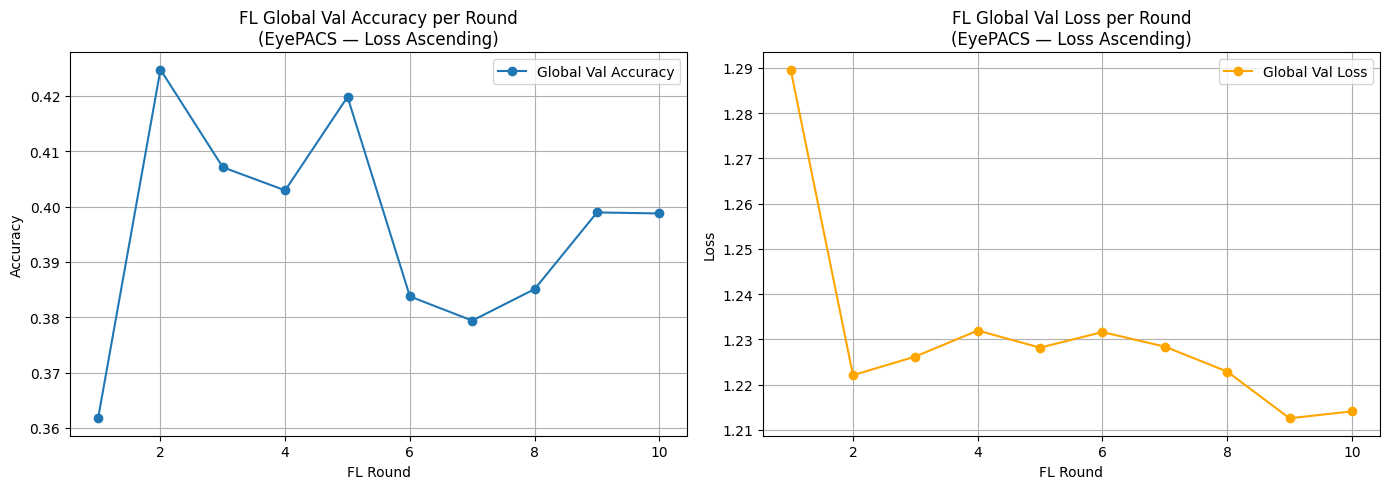

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/figures/fl_training_curve.png


In [19]:
# =========================
# CELL 17 — PLOT FL TRAINING CURVE
# =========================
rounds_list   = [r["round"]        for r in fl_round_logs]
val_acc_list  = [r["val_accuracy"] for r in fl_round_logs]
val_loss_list = [r["val_loss"]     for r in fl_round_logs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds_list, val_acc_list,  marker="o", label="Global Val Accuracy")
axes[0].set_title("FL Global Val Accuracy per Round\n(EyePACS — Loss Ascending)")
axes[0].set_xlabel("FL Round")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(rounds_list, val_loss_list, marker="o", color="orange", label="Global Val Loss")
axes[1].set_title("FL Global Val Loss per Round\n(EyePACS — Loss Ascending)")
axes[1].set_xlabel("FL Round")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

fl_curve_path = os.path.join(FIGURES_DIR, "fl_training_curve.png")
plt.savefig(fl_curve_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", fl_curve_path)

165/165 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step
Classification Report (Test Set):

              precision    recall  f1-score   support

           0     0.8349    0.4349    0.5719      3872
           1     0.0945    0.5546    0.1614       366
           2     0.2475    0.1851    0.2118       794
           3     0.1780    0.1603    0.1687       131
           4     0.1918    0.7075    0.3018       106

    accuracy                         0.4043      5269
   macro avg     0.3093    0.4085    0.2831      5269
weighted avg     0.6657    0.4043    0.4737      5269



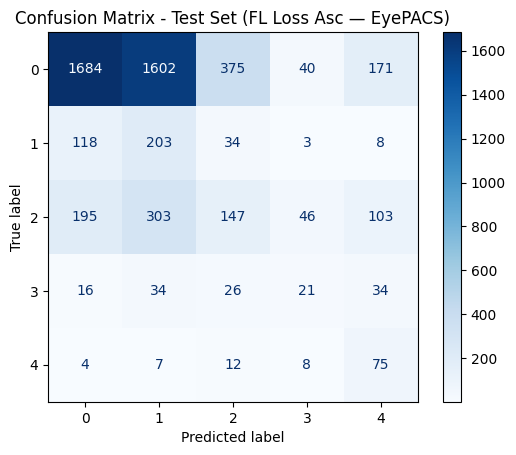

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/logs/classification_report_test.txt
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/logs/classification_report_test.json
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/logs/confusion_matrix_values_test.json
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/figures/confusion_matrix_test.png


In [20]:
# =========================
# CELL 18 — EVALUASI FINAL PADA TEST SET
# =========================
test_probs = global_model.predict(test_ds, verbose=1)
test_preds = np.argmax(test_probs, axis=1)

y_true = np.array(y_test)
y_pred = np.array(test_preds)
y_prob = np.array(test_probs)

report_text = classification_report(y_true, y_pred, digits=4)
report_dict = classification_report(y_true, y_pred, digits=4, output_dict=True)

print("Classification Report (Test Set):\n")
print(report_text)

report_txt_path  = os.path.join(LOGS_DIR, "classification_report_test.txt")
report_json_path = os.path.join(LOGS_DIR, "classification_report_test.json")

with open(report_txt_path, "w") as f:
    f.write(report_text)
with open(report_json_path, "w") as f:
    json.dump(report_dict, f, indent=4)

cm = confusion_matrix(y_true, y_pred)
cm_dict = {"confusion_matrix": cm.tolist()}
cm_json_path = os.path.join(LOGS_DIR, "confusion_matrix_values_test.json")
with open(cm_json_path, "w") as f:
    json.dump(cm_dict, f, indent=4)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(NUM_CLASSES))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Test Set (FL Loss Asc — EyePACS)")

cm_plot_path = os.path.join(FIGURES_DIR, "confusion_matrix_test.png")
plt.savefig(cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", report_txt_path)
print("Saved:", report_json_path)
print("Saved:", cm_json_path)
print("Saved:", cm_plot_path)

In [21]:
# =========================
# CELL 19 — EXTRA IMPORTS FOR METRICS
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

In [22]:
# =========================
# CELL 20 — MAIN SUMMARY TABLE
# =========================
acc = accuracy_score(y_true, y_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

y_true_bin       = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
auc_macro_ovr    = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
auc_weighted_ovr = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="weighted")

summary_df = pd.DataFrame([{
    "experiment_name":    EXPERIMENT_NAME,
    "model_name":         MODEL_NAME,
    "dataset_name":       DATASET_NAME,
    "setup":              f"FL {SORT_STRATEGY}",
    "evaluation_set":     "Test",
    "accuracy":           acc,
    "precision_macro":    precision_macro,
    "recall_macro":       recall_macro,
    "f1_macro":           f1_macro,
    "precision_weighted": precision_weighted,
    "recall_weighted":    recall_weighted,
    "f1_weighted":        f1_weighted,
    "auc_macro_ovr":      auc_macro_ovr,
    "auc_weighted_ovr":   auc_weighted_ovr,
    "train_size": len(X_train),
    "val_size":   len(X_val),
    "test_size":  len(X_test),
}])

display(summary_df)

summary_csv  = os.path.join(LOGS_DIR, "baseline_summary_table.csv")
summary_json = os.path.join(LOGS_DIR, "baseline_summary_table.json")
summary_df.to_csv(summary_csv, index=False)
summary_df.to_json(summary_json, orient="records", indent=4)

print("Saved:", summary_csv)
print("Saved:", summary_json)

,experiment_name,model_name,dataset_name,setup,evaluation_set,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auc_macro_ovr,auc_weighted_ovr,train_size,val_size,test_size
0,exp2_fl_loss_asc,mobilenet,EyePACS,FL loss_ascending,Test,0.404251,0.309325,0.408511,0.283129,0.665678,0.404251,0.473677,0.733283,0.681903,24588,5269,5269


Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/logs/baseline_summary_table.csv
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/logs/baseline_summary_table.json


In [23]:
# =========================
# CELL 21 — PER-CLASS METRICS
# =========================
precision_cls, recall_cls, f1_cls, support_cls = precision_recall_fscore_support(
    y_true, y_pred, labels=np.arange(NUM_CLASSES), zero_division=0
)

per_class_df = pd.DataFrame({
    "class":     np.arange(NUM_CLASSES),
    "precision": precision_cls,
    "recall":    recall_cls,
    "f1_score":  f1_cls,
    "support":   support_cls
})

display(per_class_df)

per_class_csv  = os.path.join(LOGS_DIR, "per_class_metrics.csv")
per_class_json = os.path.join(LOGS_DIR, "per_class_metrics.json")
per_class_df.to_csv(per_class_csv, index=False)
per_class_df.to_json(per_class_json, orient="records", indent=4)

print("Saved:", per_class_csv)
print("Saved:", per_class_json)

,class,precision,recall,f1_score,support
0,0,0.834903,0.434917,0.571914,3872
1,1,0.094463,0.554645,0.161431,366
2,2,0.247475,0.185139,0.211816,794
3,3,0.177966,0.160305,0.168675,131
4,4,0.191816,0.707547,0.301811,106


Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/logs/per_class_metrics.csv
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/logs/per_class_metrics.json


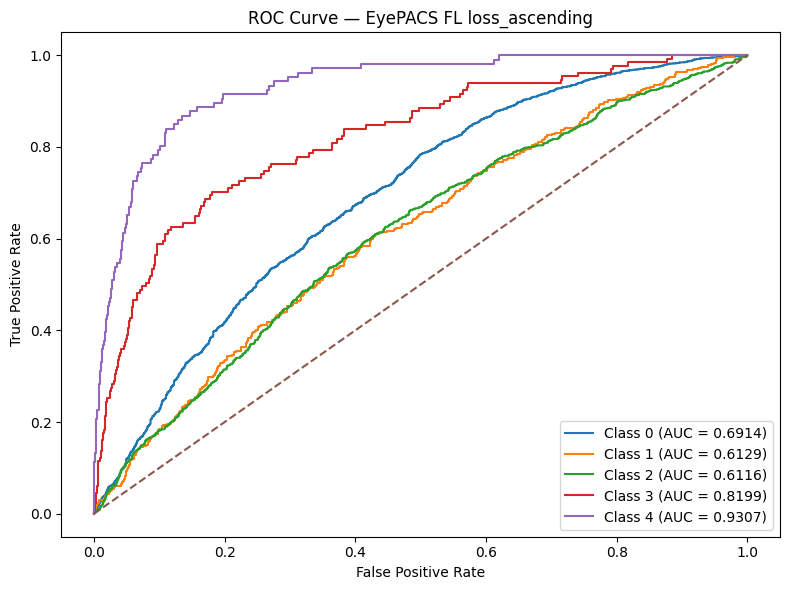

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/figures/roc_curve_baseline.png
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/logs/roc_auc_per_class.json


In [24]:
# =========================
# CELL 22 — ROC CURVE + AUC
# =========================
y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

roc_auc_per_class = {}
plt.figure(figsize=(8, 6))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc_val = auc(fpr, tpr)
    roc_auc_per_class[f"class_{i}"] = float(roc_auc_val)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc_val:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — EyePACS FL {SORT_STRATEGY}")
plt.legend()
plt.tight_layout()

roc_curve_path = os.path.join(FIGURES_DIR, "roc_curve_baseline.png")
plt.savefig(roc_curve_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

roc_auc_path = os.path.join(LOGS_DIR, "roc_auc_per_class.json")
with open(roc_auc_path, "w") as f:
    json.dump(roc_auc_per_class, f, indent=4)

print("Saved:", roc_curve_path)
print("Saved:", roc_auc_path)

<Figure size 700x600 with 0 Axes>

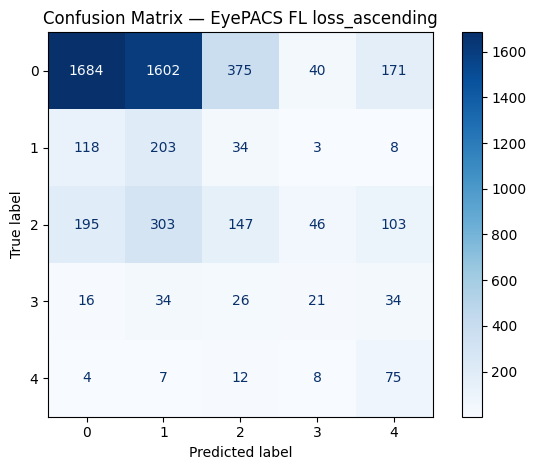

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/figures/confusion_matrix_heatmap_baseline.png
Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/logs/confusion_matrix_table.csv


In [25]:
# =========================
# CELL 23 — CONFUSION MATRIX HEATMAP
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(NUM_CLASSES))
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — EyePACS FL {SORT_STRATEGY}")
plt.tight_layout()

cm_heatmap_path = os.path.join(FIGURES_DIR, "confusion_matrix_heatmap_baseline.png")
plt.savefig(cm_heatmap_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{i}" for i in range(NUM_CLASSES)],
    columns=[f"pred_{i}" for i in range(NUM_CLASSES)]
)
cm_csv_path = os.path.join(LOGS_DIR, "confusion_matrix_table.csv")
cm_df.to_csv(cm_csv_path)

print("Saved:", cm_heatmap_path)
print("Saved:", cm_csv_path)

In [26]:
# =========================
# CELL 24 — COMPARISON READY JSON
# =========================
comparison_row = {
    "method":          f"FL_{SORT_STRATEGY}",
    "model":           MODEL_NAME,
    "dataset":         DATASET_NAME,
    "accuracy":        float(acc),
    "precision_macro": float(precision_macro),
    "recall_macro":    float(recall_macro),
    "f1_macro":        float(f1_macro),
    "auc_macro_ovr":   float(auc_macro_ovr),
    "train_size": int(len(X_train)),
    "val_size":   int(len(X_val)),
    "test_size":  int(len(X_test)),
    "fl_rounds":   FL_ROUNDS,
    "num_clients": NUM_CLIENTS,
    "notes": f"FL {SORT_STRATEGY}, {FL_ROUNDS} rounds, {NUM_CLIENTS} clients, EyePACS"
}

comparison_row_path = os.path.join(LOGS_DIR, "comparison_ready_baseline.json")
with open(comparison_row_path, "w") as f:
    json.dump(comparison_row, f, indent=4)

print("Saved:", comparison_row_path)
print(json.dumps(comparison_row, indent=4))

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/EyePACS/exp2_fl_loss_asc/mobilenet/logs/comparison_ready_baseline.json
{
    "method": "FL_loss_ascending",
    "model": "mobilenet",
    "dataset": "EyePACS",
    "accuracy": 0.4042512810780034,
    "precision_macro": 0.30932451368575326,
    "recall_macro": 0.4085106432961325,
    "f1_macro": 0.28312925499068964,
    "auc_macro_ovr": 0.7332831204369813,
    "train_size": 24588,
    "val_size": 5269,
    "test_size": 5269,
    "fl_rounds": 10,
    "num_clients": 3,
    "notes": "FL loss_ascending, 10 rounds, 3 clients, EyePACS"
}
